<a href="https://colab.research.google.com/github/rohitLanjewar03/text_classification/blob/main/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [9]:
print("Step 1: Loading the dataset (this grabs data from the internet)...")
categories = ['soc.religion.christian', 'sci.space', 'comp.graphics', 'rec.sport.hockey']

train_data = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

print(f"Loaded {len(train_data.data)} training docs and {len(test_data.data)} testing docs.")

Step 1: Loading the dataset (this grabs data from the internet)...
Loaded 2376 training docs and 1580 testing docs.


In [10]:
model = make_pipeline(
    TfidfVectorizer(),
    MultinomialNB()
)

In [11]:
print("Step 2: Training the model...")
model.fit(train_data.data, train_data.target)

Step 2: Training the model...


Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [12]:
print("Step 3: Checking accuracy...")
predicted = model.predict(test_data.data)
print(f"Accuracy: {accuracy_score(test_data.target, predicted) * 100:.2f}%")

print("\n--- Detailed Classification Report ---")
print(classification_report(test_data.target, predicted, target_names=train_data.target_names))

Step 3: Checking accuracy...
Accuracy: 93.99%

--- Detailed Classification Report ---
                        precision    recall  f1-score   support

         comp.graphics       0.98      0.87      0.92       389
      rec.sport.hockey       0.98      0.98      0.98       399
             sci.space       0.95      0.92      0.94       394
soc.religion.christian       0.86      0.98      0.92       398

              accuracy                           0.94      1580
             macro avg       0.94      0.94      0.94      1580
          weighted avg       0.94      0.94      0.94      1580



Step 4: Drawing Confusion Matrix...


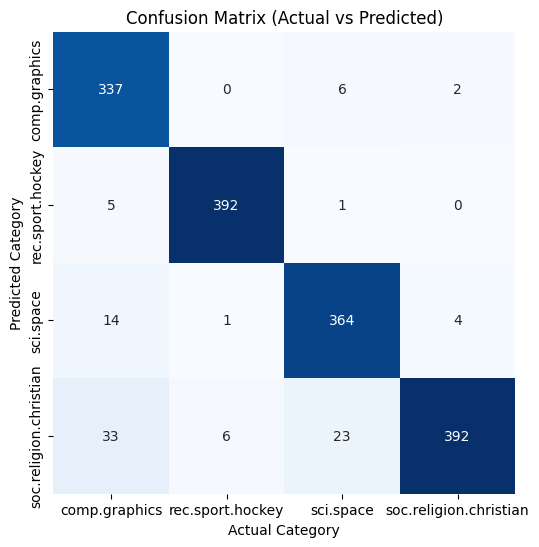

In [13]:
print("Step 4: Drawing Confusion Matrix...")
mat = confusion_matrix(test_data.target, predicted)

plt.figure(figsize=(8, 6))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train_data.target_names,
            yticklabels=train_data.target_names,
            cmap='Blues')

plt.xlabel('Actual Category')
plt.ylabel('Predicted Category')
plt.title('Confusion Matrix (Actual vs Predicted)')
plt.show()

In [14]:
print("\nStep 5: Testing on new, random sentences (The Outcome)")
print("-" * 50)

new_sentences = [
    "The GPU rendering speed is fantastic for this game.",    # Should be Graphics
    "NASA is planning a new mission to Mars next year.",      # Should be Space
    "The goalie blocked the shot in the final second.",       # Should be Hockey
    "The church service is held every Sunday morning."        # Should be Religion
]

# Predict outcome
predictions = model.predict(new_sentences)

for text, label_id in zip(new_sentences, predictions):
    category = train_data.target_names[label_id]
    print(f"Text: '{text}'")
    print(f" -> Predicted Category: {category}\n")


Step 5: Testing on new, random sentences (The Outcome)
--------------------------------------------------
Text: 'The GPU rendering speed is fantastic for this game.'
 -> Predicted Category: comp.graphics

Text: 'NASA is planning a new mission to Mars next year.'
 -> Predicted Category: sci.space

Text: 'The goalie blocked the shot in the final second.'
 -> Predicted Category: rec.sport.hockey

Text: 'The church service is held every Sunday morning.'
 -> Predicted Category: soc.religion.christian

